# 6.5) Classificador base (majority learner) - base censo 

In [1]:
import pandas as pd
base_censu_puro = pd.read_csv('../2-3-Classificacao/aula_census.csv') 
display(base_censu_puro.tail())


,age,workclass,final-weight,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loos,hour-per-week,native-country,income
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


In [2]:
base_censu_puro = base_censu_puro.rename(columns={"income": "c#income"}) # para classificar o atributo, como de classe
base_censu_puro.tail()

,age,workclass,final-weight,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loos,hour-per-week,native-country,c#income
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


In [3]:
base_censu_puro.to_csv('censusrules.csv', sep=';', index= False)

In [4]:
# coletar os dados no formato orange
import Orange

base_census = Orange.data.Table('censusrules.csv')

In [5]:
base_census.domain

[age, workclass, final-weight, education, education-num, marital-status, occupation, relationship, race, sex, capital-gain, capital-loos, hour-per-week, native-country | income]

In [6]:
# nesse caso é uma contagem simples

majority = Orange.classification.MajorityLearner()


In [8]:
# (base do census 2 vez, e o nome do objeto)
previsoes = Orange.evaluation.testing.TestOnTestData(base_census, base_census, [majority])
Orange.evaluation.CA(previsoes) #classification accuracy

array([0.75919044])

In [9]:
acuracia = Orange.evaluation.CA(previsoes)
print(f'Acurácia do modelo {acuracia[0]*100:.2f} %')

Acurácia do modelo 75.92 %


In [10]:
# acurácia do modelo

# a acurácia, lembrando que no 2-Naive_Bayes_Bayesiano.ipynb, método bayesiano a acurácia era de apenas 47,68% no census
# a acurácia, lembrando que no 3-3_Arvore_decision_Census_parte4.ipynb, método da árvore de decisão simples a acurácia era de 81,04% no census
# a acurácia, lembrando que no 3-5_Arvore_decision_Random_Forest_Census.ipynb método das múltiplas árvores => A acurácia do modelo é de 85.08% para 100 árvores (n_estimators).


assim o naive bayes é pior do que o Majority Learner (que é o padrão)

os algoritmos que ficam acima da linha base padrão (do Majority Learner) são os melhores para serem utilizados


### a acurácia, lembrando que no 2-Naive_Bayes_Bayesiano.ipynb, método bayesiano a acurácia era de apenas 47,68% no census

### a acurácia, lembrando que no 3-3_Arvore_decision_Census_parte4.ipynb, método da árvore de decisão simples a acurácia era de 81,04% no census

### a acurácia, lembrando que no 3-5_Arvore_decision_Random_Forest_Census.ipynb método das múltiplas árvores => A acurácia do modelo é de 85.08% para 100 árvores (n_estimators).

no programa orange ficou em mais de 80%=CA(classification accuracy) a modelagem pela Regra


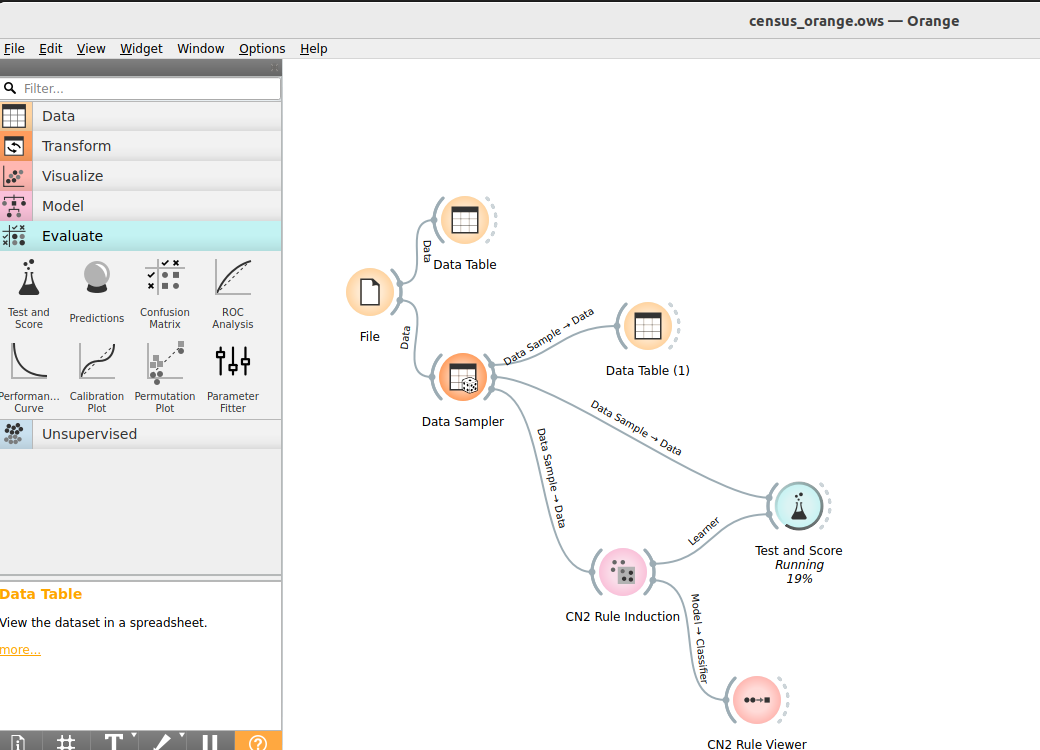


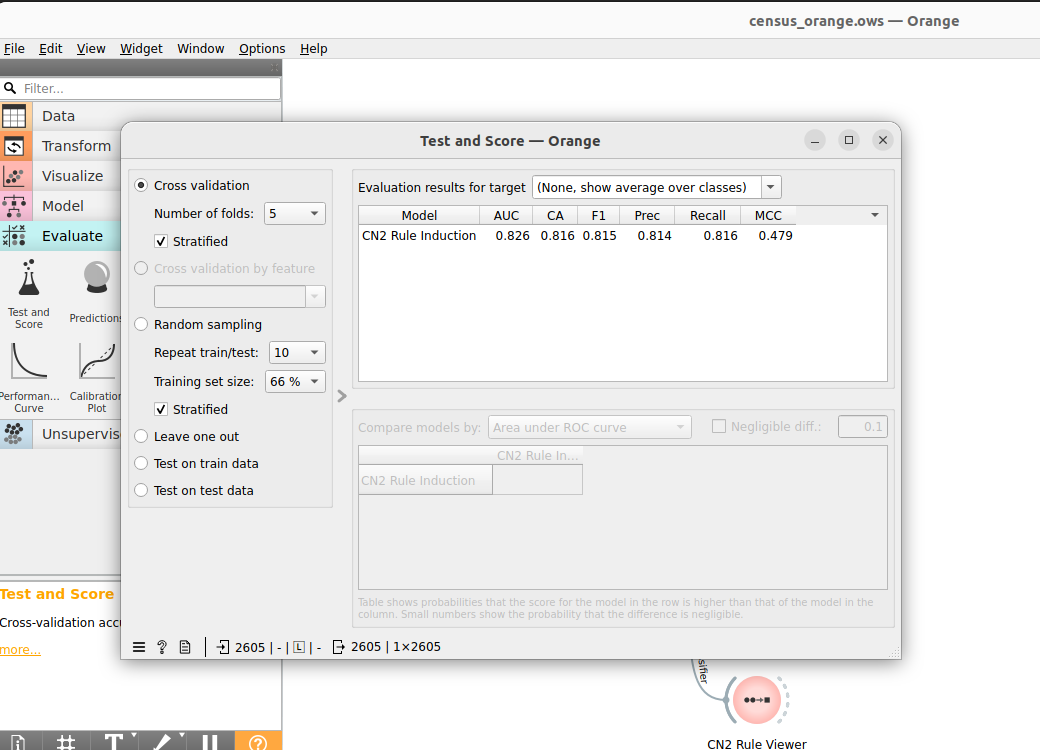



Contar o registro de cada classe


In [12]:
from collections import Counter
Counter(str(registro.get_class()) for registro in base_census)

Counter({'<=50K': 24720, '>50K': 7841})

In [13]:
24720/(24720+7841)

0.7591904425539756

In [15]:
# percentual mínimo de acerto


#assim o naive bayes é pior do que o Majority Learner (que é o padrão)

#os algoritmos que ficam acima da linha base padrão (do Majority Learner) são os melhores para serem utilizados

# comparar sempre os algoritmos 